<a href="https://colab.research.google.com/github/Somya456/Image-Segmentation-for-Disaster-Resilience/blob/main/Model_training_UNet.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
import cv2

import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.optimizers import Adam
import tensorflow.keras.backend as K

import albumentations as A

print("TensorFlow Version :", tf.__version__)

TensorFlow Version : 2.20.0


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
DATASET_PATH = "/content/drive/MyDrive/Infyntrek DS&ML Group 1 - Task 3"
# Training

X_train = np.load(os.path.join(DATASET_PATH, "X_train.npy"))
Y_train = np.load(os.path.join(DATASET_PATH, "Y_train.npy"))

# Validation

X_val = np.load(os.path.join(DATASET_PATH, "X_val.npy"))
Y_val = np.load(os.path.join(DATASET_PATH, "Y_val.npy"))

# Testing

X_test = np.load(os.path.join(DATASET_PATH, "X_test.npy"))
Y_test = np.load(os.path.join(DATASET_PATH, "Y_test.npy"))

In [4]:
Y_train = Y_train.astype(np.float32)
Y_val = Y_val.astype(np.float32)
Y_test = Y_test.astype(np.float32)

print(Y_train.dtype)

float32


In [5]:
print("="*50)
print("Training :", X_train.shape, Y_train.shape)
print("Validation :", X_val.shape, Y_val.shape)
print("Testing :", X_test.shape, Y_test.shape)

print()

print("Image Range :", X_train.min(), X_train.max())

print("Mask Values :", np.unique(Y_train))

Training : (2720, 256, 256, 3) (2720, 256, 256, 1)
Validation : (340, 256, 256, 3) (340, 256, 256, 1)
Testing : (341, 256, 256, 3) (341, 256, 256, 1)

Image Range : 0.0 1.0
Mask Values : [0. 1.]


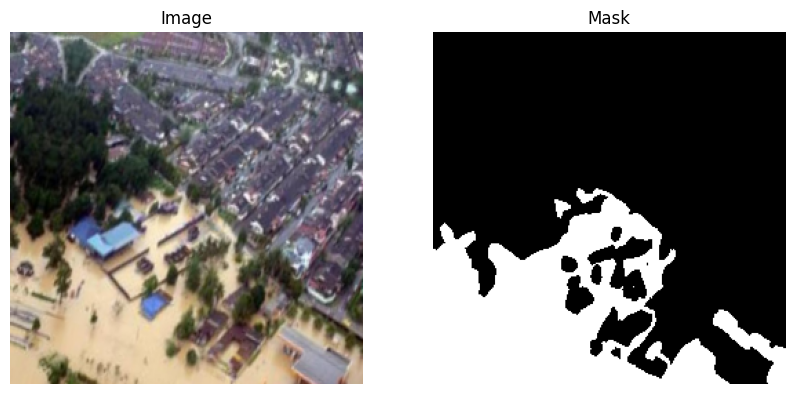

In [6]:
idx = random.randint(0, len(X_train)-1)

plt.figure(figsize=(10,5))

plt.subplot(1,2,1)
plt.imshow(X_train[idx])
plt.title("Image")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(Y_train[idx].squeeze(), cmap="gray")
plt.title("Mask")
plt.axis("off")

plt.show()

In [7]:
train_transform = A.Compose([

    A.HorizontalFlip(p=0.5),

    A.VerticalFlip(p=0.5),

    A.RandomRotate90(p=0.5),

    A.Rotate(
        limit=20,
        border_mode=cv2.BORDER_CONSTANT,
        p=0.5
    ),

    A.RandomBrightnessContrast(
        brightness_limit=0.2,
        contrast_limit=0.2,
        p=0.5
    )

])

In [8]:
def augment_image(image, mask):

    augmented = train_transform(
        image=image,
        mask=mask
    )

    image = augmented["image"]

    mask = augmented["mask"]

    mask = (mask > 0).astype(np.float32)

    return image, mask

In [9]:
def data_generator(
    images,
    masks,
    batch_size=8,
    augment=False
):

    while True:

        indices = np.random.permutation(len(images))

        for start in range(0, len(images), batch_size):

            end = start + batch_size

            batch_indices = indices[start:end]

            batch_images = []

            batch_masks = []

            for idx in batch_indices:

                image = images[idx]

                mask = masks[idx]

                if augment:

                    image, mask = augment_image(
                        image,
                        mask
                    )

                batch_images.append(
                    image.astype(np.float32)
                )

                batch_masks.append(
                    mask.astype(np.float32)
                )

            yield (
                np.array(batch_images),
                np.array(batch_masks)
            )

In [10]:
BATCH_SIZE = 8

train_generator = data_generator(

    X_train,

    Y_train,

    batch_size=BATCH_SIZE,

    augment=True
)

val_generator = data_generator(

    X_val,

    Y_val,

    batch_size=BATCH_SIZE,

    augment=False
)

train_steps = len(X_train) // BATCH_SIZE

val_steps = len(X_val) // BATCH_SIZE

In [11]:
# ============================================
# Dice Coefficient
# ============================================

def dice_coefficient(y_true, y_pred):

    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    smooth = 1e-6

    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)

    intersection = K.sum(y_true_f * y_pred_f)

    return (2. * intersection + smooth) / (
        K.sum(y_true_f) +
        K.sum(y_pred_f) +
        smooth
    )

In [12]:
# ============================================
# Dice Loss
# ============================================

def dice_loss(y_true, y_pred):

    return 1 - dice_coefficient(y_true, y_pred)

In [13]:
# ============================================
# IoU Score
# ============================================

def iou_score(y_true, y_pred):

    y_true = tf.cast(y_true, tf.float32)
    y_pred = tf.cast(y_pred, tf.float32)

    smooth = 1e-6

    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)

    intersection = K.sum(y_true_f * y_pred_f)

    union = (
        K.sum(y_true_f)
        + K.sum(y_pred_f)
        - intersection
    )

    return (intersection + smooth) / (union + smooth)

In [14]:
# ============================================
# Combined Loss
# ============================================

bce = tf.keras.losses.BinaryCrossentropy()

def combined_loss(y_true, y_pred):

    return bce(y_true, y_pred) + dice_loss(y_true, y_pred)

In [15]:
# ============================================
# Convolution Block
# ============================================

def conv_block(inputs, filters, dropout_rate=0.0):

    x = layers.Conv2D(
        filters,
        (3,3),
        padding="same",
        kernel_initializer="he_normal"
    )(inputs)

    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.Conv2D(
        filters,
        (3,3),
        padding="same",
        kernel_initializer="he_normal"
    )(x)

    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    if dropout_rate > 0:
        x = layers.Dropout(dropout_rate)(x)

    return x

In [16]:
# ============================================
# Encoder Block
# ============================================

def encoder_block(inputs, filters, dropout_rate=0):

    x = conv_block(inputs, filters, dropout_rate)

    p = layers.MaxPooling2D((2,2))(x)

    return x, p

In [17]:
# ============================================
# Decoder Block
# ============================================

def decoder_block(inputs, skip_features, filters):

    x = layers.Conv2DTranspose(
        filters,
        kernel_size=2,
        strides=2,
        padding="same"
    )(inputs)

    x = layers.Concatenate()([x, skip_features])

    x = conv_block(x, filters)

    return x

In [18]:
# ============================================
# Enhanced U-Net
# ============================================

def build_unet(input_shape=(256,256,3)):

    inputs = layers.Input(shape=input_shape)

    # Encoder
    s1, p1 = encoder_block(inputs, 32)

    s2, p2 = encoder_block(p1, 64)

    s3, p3 = encoder_block(
        p2,
        128,
        dropout_rate=0.1
    )

    s4, p4 = encoder_block(
        p3,
        256,
        dropout_rate=0.2
    )

    # Bottleneck
    b1 = conv_block(
        p4,
        512,
        dropout_rate=0.3
    )

    # Decoder
    d1 = decoder_block(b1, s4, 256)

    d2 = decoder_block(d1, s3, 128)

    d3 = decoder_block(d2, s2, 64)

    d4 = decoder_block(d3, s1, 32)

    outputs = layers.Conv2D(
        1,
        (1,1),
        activation="sigmoid"
    )(d4)

    model = Model(
        inputs,
        outputs,
        name="Enhanced_UNet"
    )

    return model

In [19]:
unet_model = build_unet()

unet_model.summary()

Model: "Enhanced_UNet"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256, 256,  │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │      9,248 │ activation[0][0]  │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │     36,928 │ activation_2[0][… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        256 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 64, 64,    │     73,856 │ max_pooling2d_1[… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 64,    │        512 │ conv2d_4[0][0]  

 Total params: 7,771,873 (29.65 MB)

 Trainable params: 7,765,985 (29.62 MB)

 Non-trainable params: 5,888 (23.00 KB)

In [20]:
unet_model.compile(

    optimizer=Adam(learning_rate=1e-3),

    loss=combined_loss,

    metrics=[
        "accuracy",
        dice_coefficient,
        iou_score
    ]
)

In [21]:
# ============================================
# Callbacks
# ============================================

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    filepath=os.path.join(DATASET_PATH, "enhanced_unet_best.keras"),
    monitor="val_loss",
    save_best_only=True,
    verbose=1
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=4,
    min_lr=1e-6,
    verbose=1
)

In [22]:
# ============================================
# Train Model
# ============================================

EPOCHS = 25

history_unet = unet_model.fit(
    train_generator,
    steps_per_epoch=train_steps,
    validation_data=val_generator,
    validation_steps=val_steps,
    epochs=EPOCHS,
    callbacks=[
        checkpoint,
        early_stop,
        reduce_lr
    ]
)

Epoch 1/25
340/340 ━━━━━━━━━━━━━━━━━━━━ 0s 174ms/step - accuracy: 0.8075 - dice_coefficient: 0.7075 - iou_score: 0.5516 - loss: 0.7331
Epoch 1: val_loss improved from None to 0.62647, saving model to /content/drive/MyDrive/Infyntrek DS&ML Group 1 - Task 3/enhanced_unet_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/Infyntrek DS&ML Group 1 - Task 3/enhanced_unet_best.keras
340/340 ━━━━━━━━━━━━━━━━━━━━ 116s 190ms/step - accuracy: 0.8364 - dice_coefficient: 0.7356 - iou_score: 0.5846 - loss: 0.6544 - val_accuracy: 0.8325 - val_dice_coefficient: 0.7781 - val_iou_score: 0.6394 - val_loss: 0.6265 - learning_rate: 0.0010
Epoch 2/25
340/340 ━━━━━━━━━━━━━━━━━━━━ 0s 183ms/step - accuracy: 0.8616 - dice_coefficient: 0.7649 - iou_score: 0.6217 - loss: 0.5736
Epoch 2: val_loss did not improve from 0.62647
340/340 ━━━━━━━━━━━━━━━━━━━━ 65s 190ms/step - accuracy: 0.8607 - dice_coefficient: 0.7684 - iou_score: 0.6262 - loss: 0.5712 - val_accuracy: 0.8454 - val_dice_coefficient: 0.

In [23]:
# ============================================
# Evaluate on Test Set
# ============================================

results = unet_model.evaluate(
    X_test,
    Y_test,
    verbose=1,
    return_dict=True
)

print("\nTest Results")
print("-"*40)

for key, value in results.items():
    print(f"{key:<20}: {value:.4f}")

11/11 ━━━━━━━━━━━━━━━━━━━━ 37s 2s/step - accuracy: 0.9233 - dice_coefficient: 0.8774 - iou_score: 0.7817 - loss: 0.3279

Test Results
----------------------------------------
accuracy            : 0.9233
dice_coefficient    : 0.8774
iou_score           : 0.7817
loss                : 0.3279


In [24]:
# ============================================
# Save Model
# ============================================

model_path = os.path.join(DATASET_PATH, "enhanced_unet_final.keras")

unet_model.save(model_path)

print(f"Model saved to:\n{model_path}")

Model saved to:
/content/drive/MyDrive/Infyntrek DS&ML Group 1 - Task 3/enhanced_unet_final.keras


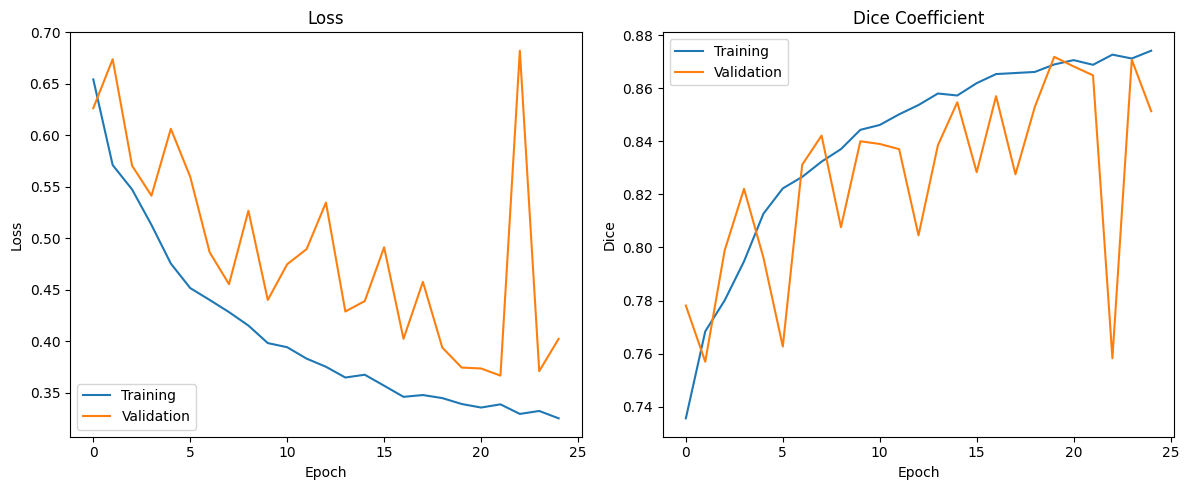

In [25]:
# ============================================
# Training Curves
# ============================================

plt.figure(figsize=(12,5))

# Loss
plt.subplot(1,2,1)
plt.plot(history_unet.history["loss"], label="Training")
plt.plot(history_unet.history["val_loss"], label="Validation")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

# Dice
plt.subplot(1,2,2)
plt.plot(history_unet.history["dice_coefficient"], label="Training")
plt.plot(history_unet.history["val_dice_coefficient"], label="Validation")
plt.title("Dice Coefficient")
plt.xlabel("Epoch")
plt.ylabel("Dice")
plt.legend()

plt.tight_layout()
plt.show()

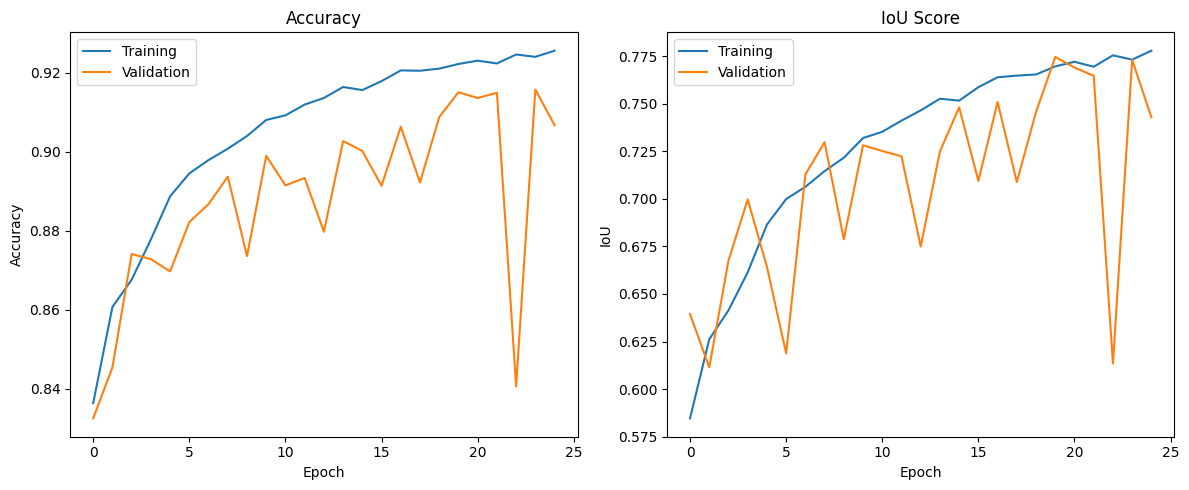

In [26]:
plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)
plt.plot(history_unet.history["accuracy"], label="Training")
plt.plot(history_unet.history["val_accuracy"], label="Validation")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# IoU
plt.subplot(1,2,2)
plt.plot(history_unet.history["iou_score"], label="Training")
plt.plot(history_unet.history["val_iou_score"], label="Validation")
plt.title("IoU Score")
plt.xlabel("Epoch")
plt.ylabel("IoU")
plt.legend()

plt.tight_layout()
plt.show()

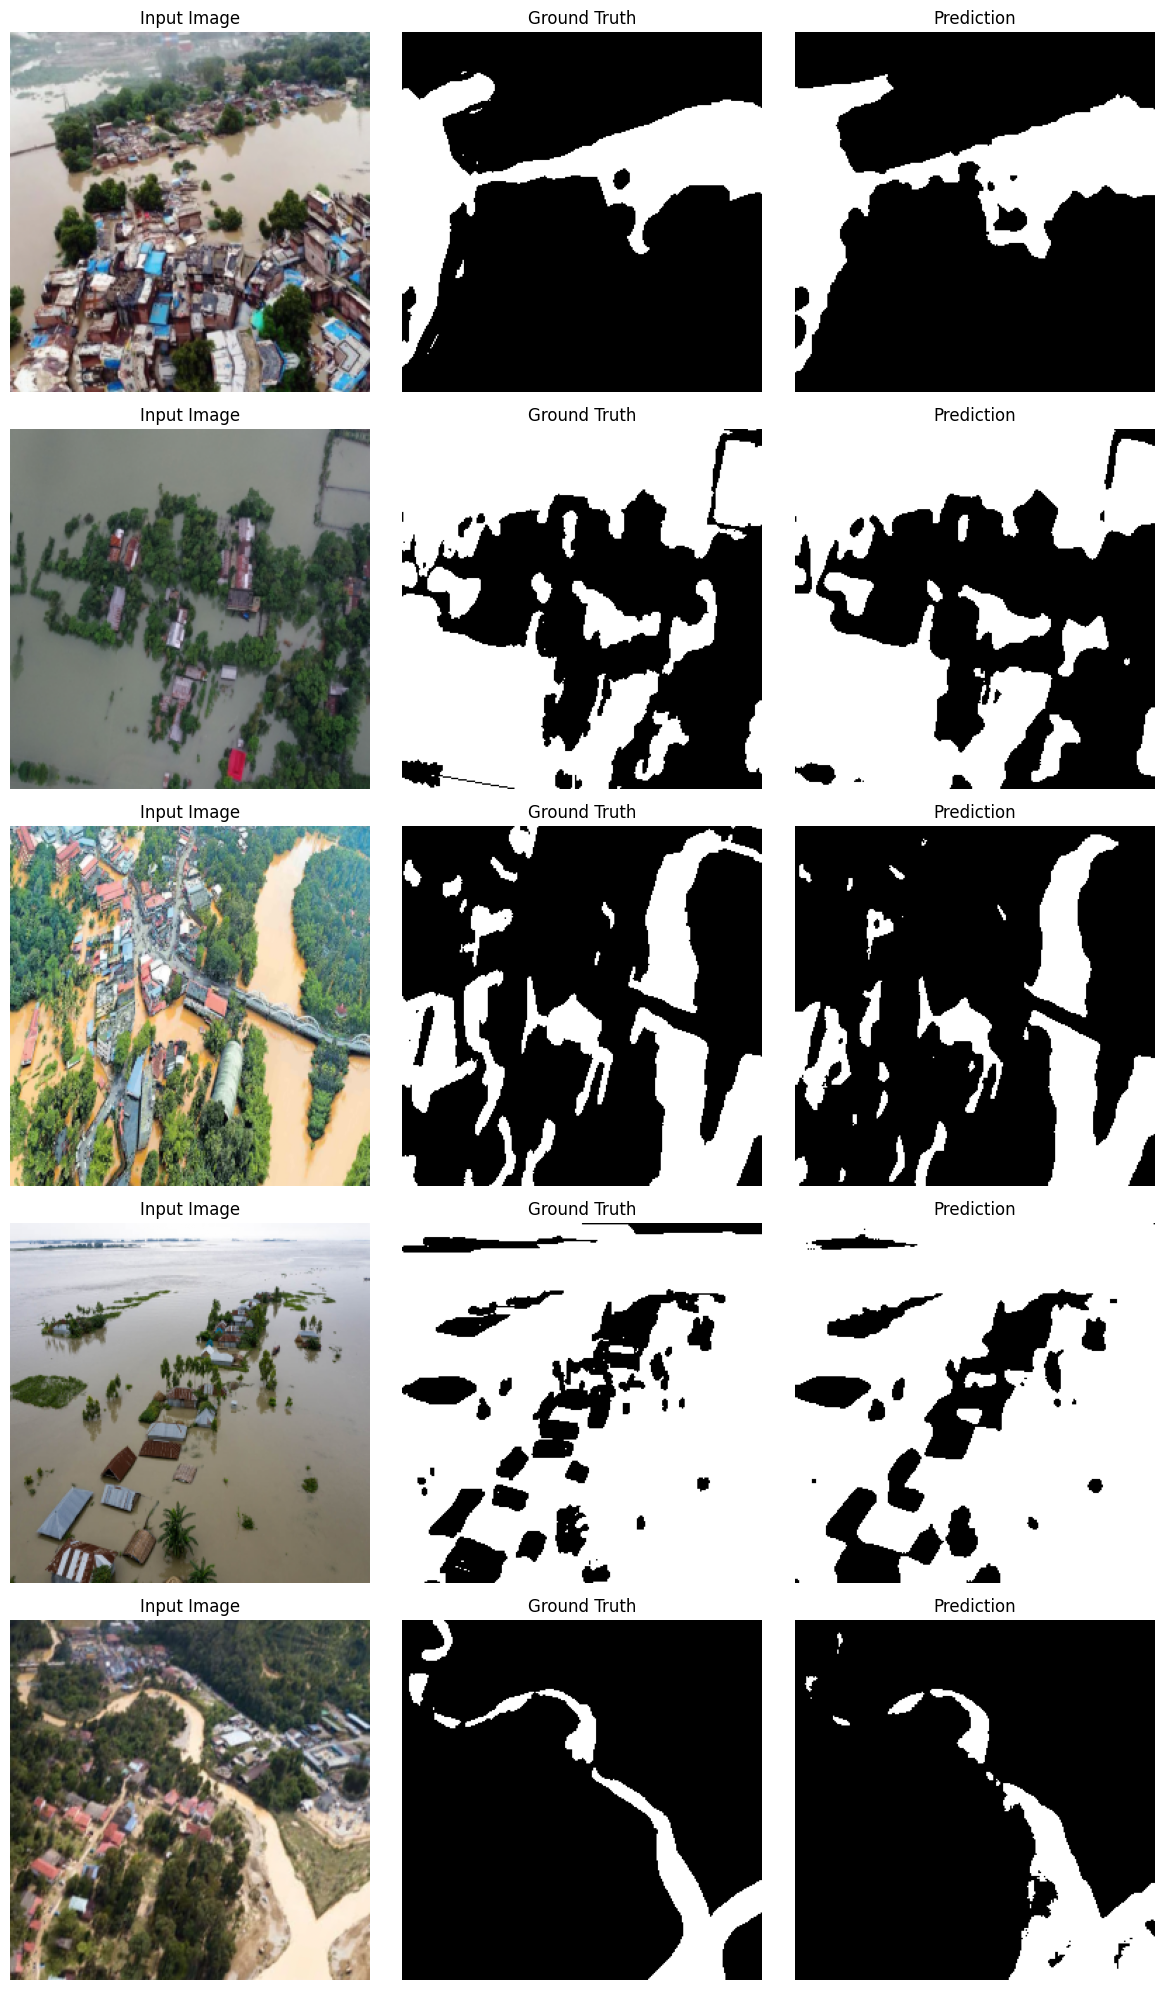

In [27]:
# ============================================
# Visualize Predictions
# ============================================

num_samples = 5
indices = np.random.choice(len(X_test), num_samples, replace=False)

plt.figure(figsize=(12, num_samples * 4))

for i, idx in enumerate(indices):

    image = X_test[idx]
    true_mask = Y_test[idx]

    pred = unet_model.predict(
        np.expand_dims(image, axis=0),
        verbose=0
    )[0]

    pred = (pred > 0.5).astype(np.uint8)

    # Original Image
    plt.subplot(num_samples, 3, 3*i + 1)
    plt.imshow(image)
    plt.title("Input Image")
    plt.axis("off")

    # Ground Truth
    plt.subplot(num_samples, 3, 3*i + 2)
    plt.imshow(true_mask.squeeze(), cmap="gray")
    plt.title("Ground Truth")
    plt.axis("off")

    # Prediction
    plt.subplot(num_samples, 3, 3*i + 3)
    plt.imshow(pred.squeeze(), cmap="gray")
    plt.title("Prediction")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [28]:
print("="*50)
print("Enhanced U-Net Performance")
print("="*50)

for key, value in results.items():
    print(f"{key:<20}: {value:.4f}")

Enhanced U-Net Performance
accuracy            : 0.9233
dice_coefficient    : 0.8774
iou_score           : 0.7817
loss                : 0.3279
